In [21]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [22]:
# read dataset and keep only needed columns
df = pd.read_csv('cleaned_data.csv')
df = df[['cleaned_posts', 'personality_type']]

print("Dataset loaded.")
print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(2))


Dataset loaded.
Total rows: 8675
Columns: ['cleaned_posts', 'personality_type']
                                       cleaned_posts personality_type
0  ' and   moments    sportscenter not top ten pl...                I
1  'i'm finding the lack of me in these posts ver...                E


In [23]:
# create some useful text-based features

# number of words per post
df['word_count'] = df['cleaned_posts'].apply(
    lambda x: len(str(x).split())
)

# number of characters per post
df['char_count'] = df['cleaned_posts'].apply(
    lambda x: len(str(x))
)

# average word length in each post
df['avg_word_length'] = df['cleaned_posts'].apply(
    lambda x: sum(len(w) for w in str(x).split()) / max(len(str(x).split()), 1)
)

print("\nFeatures added.")
print(df[['word_count', 'char_count', 'avg_word_length']].describe())


Features added.
        word_count   char_count  avg_word_length
count  8675.000000  8675.000000      8675.000000
mean   1262.005764  6902.466974         4.428483
std     316.004540  1703.507776         0.183206
min       4.000000    12.000000         2.000000
25%    1082.000000  5926.000000         4.308033
50%    1314.000000  7203.000000         4.422179
75%    1496.000000  8161.500000         4.538336
max    1921.000000  9918.000000         6.269231


In [24]:
# keep colours across plots
PALETTE = {'I': '#4C72B0', 'E': '#DD8452'}
sns.set_style("whitegrid")
sns.set_context("talk")

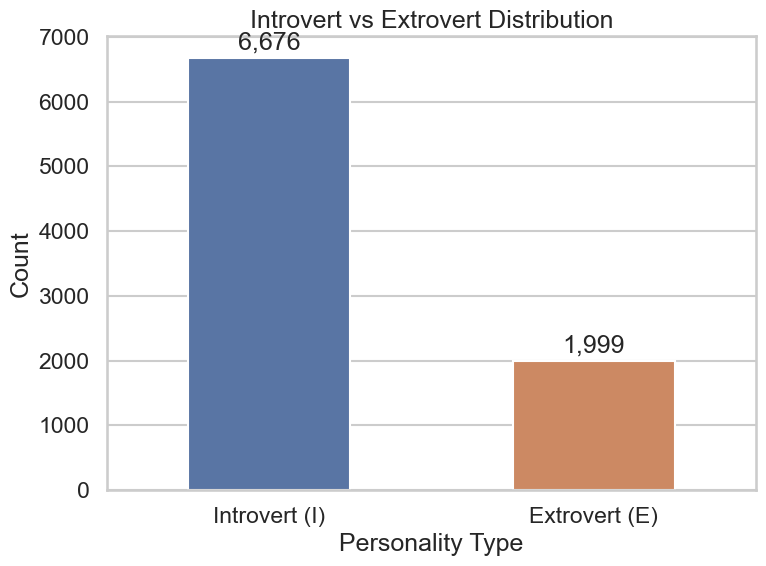

In [25]:
# VISUALISATION 1: Count of Introverts vs Extroverts
# simple count of introverts vs extroverts

counts = df['personality_type'].value_counts().reset_index()
counts.columns = ['personality_type', 'count']

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=counts,
    x='personality_type',
    y='count',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.5,
    legend=False
)

# add values on top
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom'
    )

ax.set_title('Introvert vs Extrovert Distribution')
ax.set_xlabel('Personality Type')
ax.set_ylabel('Count')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'])

plt.tight_layout()
plt.savefig('viz1_introvert_vs_extrovert_count.png', dpi=150)
plt.show()

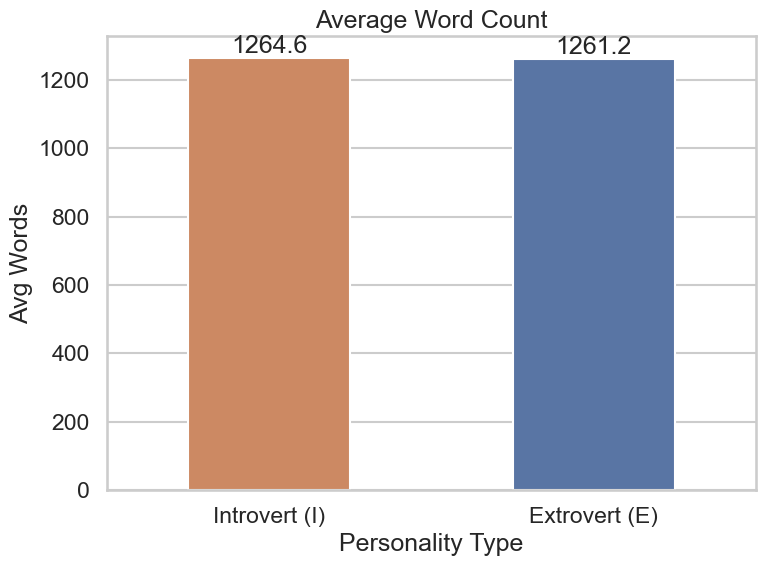

In [26]:

# VISUALISATION 2: Avg word count
# compares average words used

avg_wc = df.groupby('personality_type')['word_count'].mean().reset_index()
avg_wc.columns = ['personality_type', 'avg_word_count']

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=avg_wc,
    x='personality_type',
    y='avg_word_count',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.5,
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}',
        ha='center', va='bottom'
    )

ax.set_title('Average Word Count')
ax.set_xlabel('Personality Type')
ax.set_ylabel('Avg Words')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'])

plt.tight_layout()
plt.savefig('viz2_avg_word_count.png', dpi=150)
plt.show()

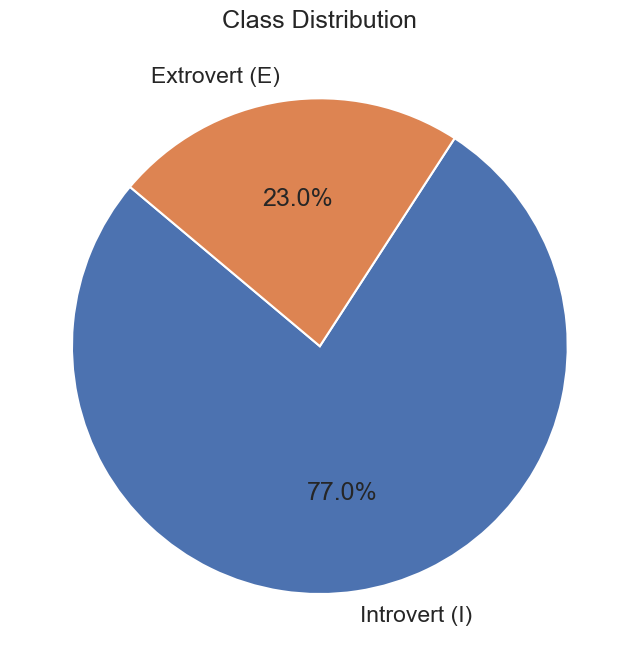

In [27]:

# VISUALISATION 3: Pie chart
# shows percentage split

labels = ['Introvert (I)', 'Extrovert (E)']
sizes = df['personality_type'].value_counts().values
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(7, 7))

ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

ax.set_title('Class Distribution')

plt.tight_layout()
plt.savefig('viz3_class_distribution_pie.png', dpi=150)
plt.show()

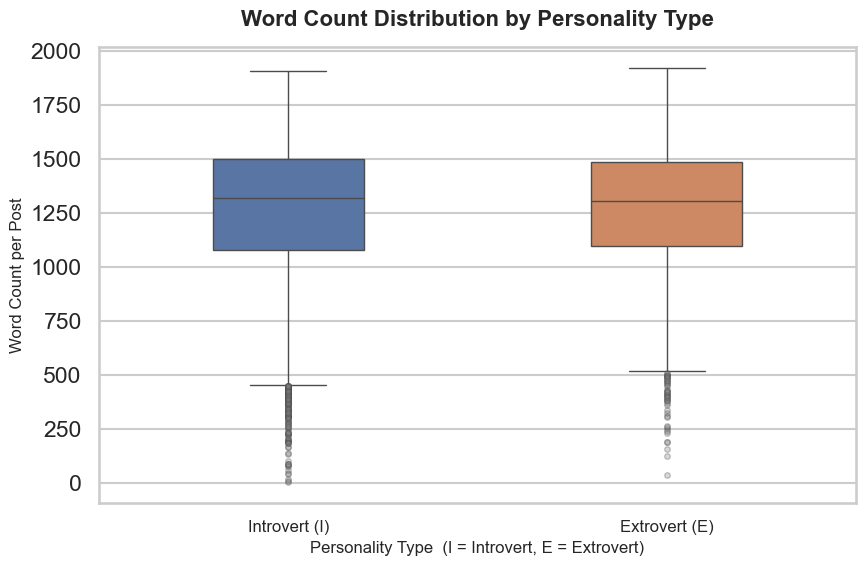

Visualisation 4 saved.


In [28]:

# VISUALISATION 4: Boxplot
# shows spread of word counts


fig, ax = plt.subplots(figsize=(9, 6))
 
sns.boxplot(
    data=df,
    x='personality_type',
    y='word_count',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.4,
    legend=False,
    flierprops=dict(marker='o', markerfacecolor='grey',
                    markersize=4, alpha=0.3)
)
 
ax.set_title('Word Count Distribution by Personality Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Personality Type  (I = Introvert, E = Extrovert)',
              fontsize=12)
ax.set_ylabel('Word Count per Post', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'], fontsize=12)
 
plt.tight_layout()
plt.savefig('viz4_word_count_boxplot.png', dpi=150)
plt.show()
print("Visualisation 4 saved.")

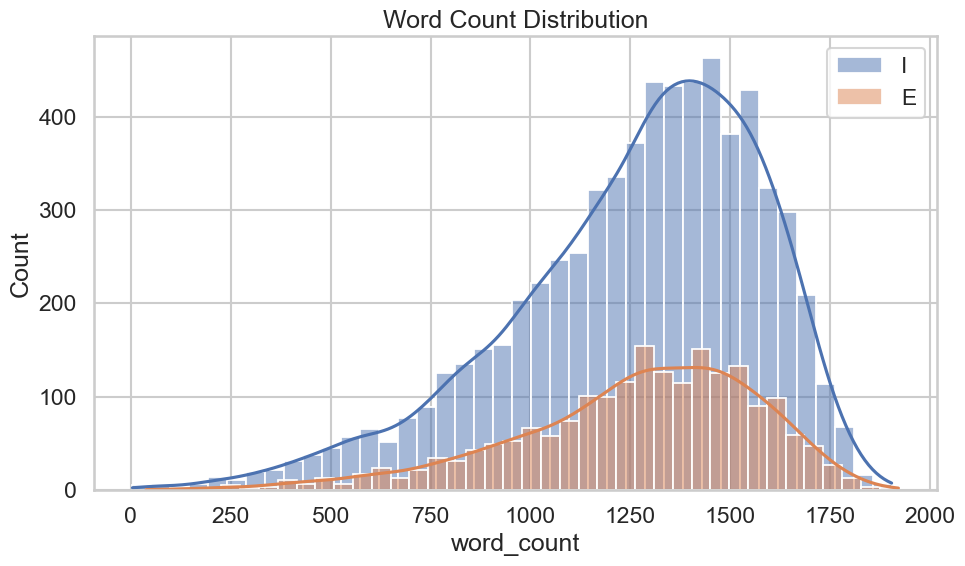

In [29]:

# VISUALISATION 5: Histogram
# compare distributions

fig, ax = plt.subplots(figsize=(10, 6))

for ptype, color in PALETTE.items():
    sns.histplot(
        data=df[df['personality_type'] == ptype],
        x='word_count',
        color=color,
        alpha=0.5,
        bins=40,
        kde=True,
        label=ptype,
        ax=ax
    )

ax.set_title('Word Count Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('viz5_word_count_histogram.png', dpi=150)
plt.show()

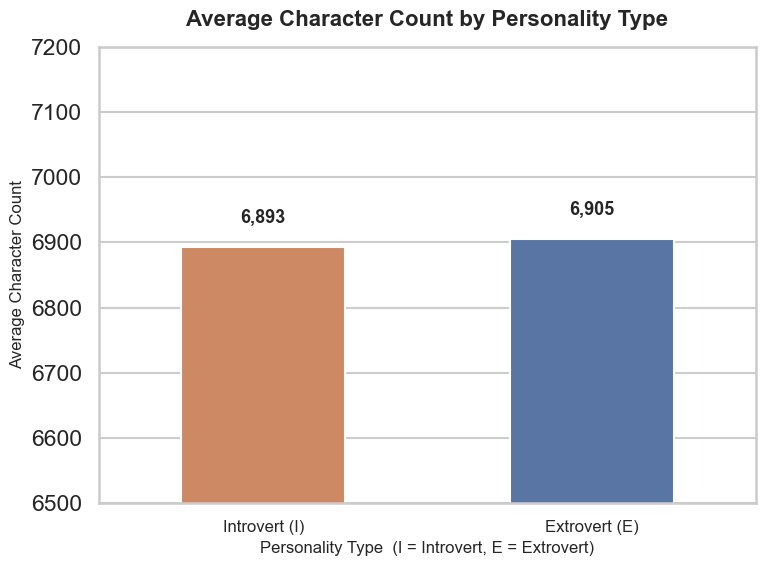

Visualisation 6 saved.


In [30]:

# VISUALISATION 6: Avg char count


avg_cc = df.groupby('personality_type')['char_count'].mean().reset_index()
avg_cc.columns = ['personality_type', 'avg_char_count']
 
fig, ax = plt.subplots(figsize=(8, 6))
 
sns.barplot(
    data=avg_cc,
    x='personality_type',
    y='avg_char_count',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.5,
    legend=False
)
 
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{bar.get_height():,.0f}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )
 
ax.set_title('Average Character Count by Personality Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Personality Type  (I = Introvert, E = Extrovert)',
              fontsize=12)
ax.set_ylabel('Average Character Count', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'], fontsize=12)
ax.set_ylim(6500, 7200)
 
plt.tight_layout()
plt.savefig('viz7_avg_char_count.png', dpi=150)
plt.show()
print("Visualisation 6 saved.")

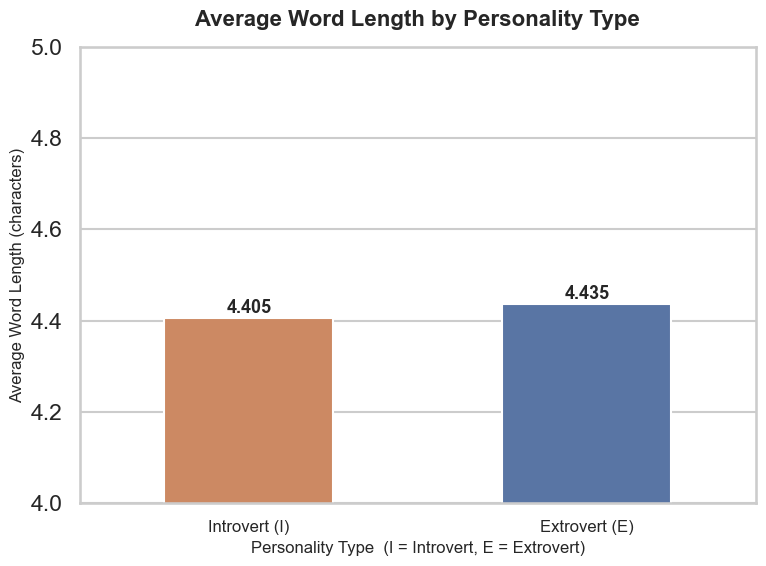

Visualisation 7 saved.

 All 8 visualisations complete and saved.


In [31]:

# VISUALISATION 7: Avg word length

avg_wl = df.groupby('personality_type')['avg_word_length'].mean().reset_index()
avg_wl.columns = ['personality_type', 'avg_word_length']
 
fig, ax = plt.subplots(figsize=(8, 6))
 
sns.barplot(
    data=avg_wl,
    x='personality_type',
    y='avg_word_length',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.5,
    legend=False
)
 
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )
 
ax.set_title('Average Word Length by Personality Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Personality Type  (I = Introvert, E = Extrovert)',
              fontsize=12)
ax.set_ylabel('Average Word Length (characters)', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'], fontsize=12)
ax.set_ylim(4.0, 5.0)
 
plt.tight_layout()
plt.savefig('viz8_avg_word_length.png', dpi=150)
plt.show()
print("Visualisation 7 saved.")
 
 
print("\n All 8 visualisations complete and saved.")
 

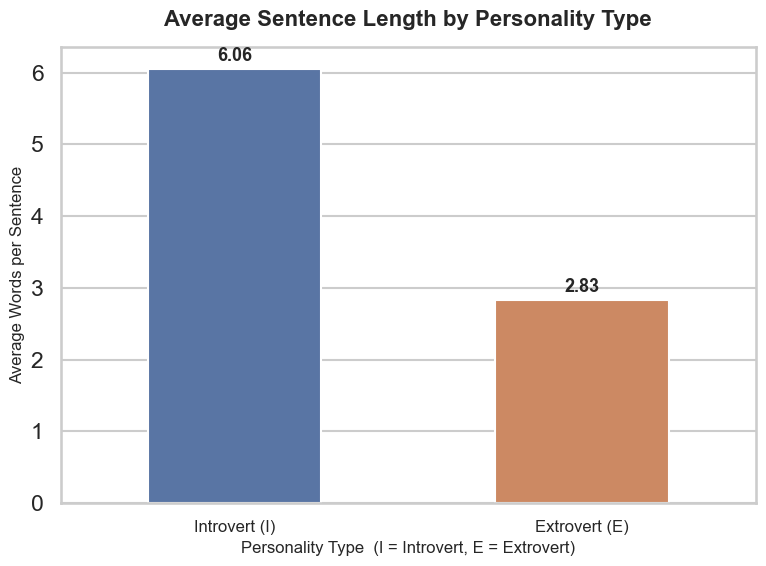

Visualisation 8 saved.


In [32]:

# VISUALISATION 8 (CREATIVE):
# Bar Chart — Average Sentence Length by Personality Type
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = ['#4C72B0', '#DD8452']
data = {
    'personality_type': ['I', 'I', 'E', 'E', 'I', 'E'],
    'cleaned_posts': [
        "This is a test. This is another test!",
        "How are you doing? I am fine.",
        "Short sentence. Another short one.",
        "I like to write long, detailed sentences that contain multiple clauses and ideas.",
        "Test?",
        "Hello there! How are you today? I'm good."
    ]
}
df = pd.DataFrame(data)

def avg_sentence_length(text):
    # Split post into sentences on . ! or ?
    sentences = re.split(r'[.!?]+', str(text))
    # Remove empty strings from the list
    sentences = [s.strip() for s in sentences if s.strip()]
    if len(sentences) == 0:
        return 0
    # Count words in each sentence, calculate avergae
    lengths = [len(s.split()) for s in sentences]
    return sum(lengths) / len(lengths)

# Apply the function to every row in the dataset
df['avg_sentence_length'] = df['cleaned_posts'].apply(avg_sentence_length)

# Calculate the mean sentence length per personality type
avg_sl = df.groupby('personality_type')['avg_sentence_length'].mean().reset_index()
avg_sl.columns = ['personality_type', 'avg_sentence_length']

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=avg_sl,
    x='personality_type',
    y='avg_sentence_length',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.5,
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{bar.get_height():.2f}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )

ax.set_title('Average Sentence Length by Personality Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Personality Type  (I = Introvert, E = Extrovert)', fontsize=12)
ax.set_ylabel('Average Words per Sentence', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'], fontsize=12)

plt.tight_layout()
plt.savefig('viz9_avg_sentence_length.png', dpi=150)
plt.show()
print("Visualisation 8 saved.")
  

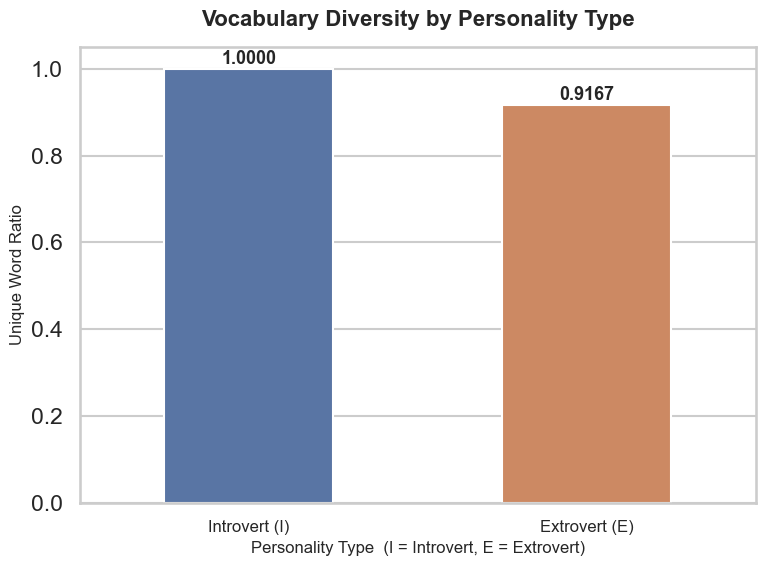

Visualisation 9 saved.


In [33]:

# VISUALISATION 9: Vocabulary diversity
def unique_word_ratio(text):
    words = str(text).split()
    if len(words) == 0:
        return 0
    # set() removes duplicates, so len(set()) = unique word count
    return len(set(words)) / len(words)

# Apply the function to every row
df['unique_word_ratio'] = df['cleaned_posts'].apply(unique_word_ratio)

# Calculate the mean ratio per personality type
avg_uwr = df.groupby('personality_type')['unique_word_ratio'].mean().reset_index()
avg_uwr.columns = ['personality_type', 'avg_unique_word_ratio']

fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    data=avg_uwr,
    x='personality_type',
    y='avg_unique_word_ratio',
    hue='personality_type',
    palette=PALETTE,
    ax=ax,
    width=0.5,
    legend=False
)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold'
    )

ax.set_title('Vocabulary Diversity by Personality Type',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Personality Type  (I = Introvert, E = Extrovert)', fontsize=12)
ax.set_ylabel('Unique Word Ratio', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Introvert (I)', 'Extrovert (E)'], fontsize=12)

plt.tight_layout()
plt.savefig('viz10_vocabulary_diversity.png', dpi=150)
plt.show()
print("Visualisation 9 saved.")